In [1]:
using MarineHydro
import Meshes as Meshes
using CairoMakie: CairoMakie as Makie
using Unitful: m, ustrip, Length, u, @u_str
using LinearAlgebra: cross, dot, norm


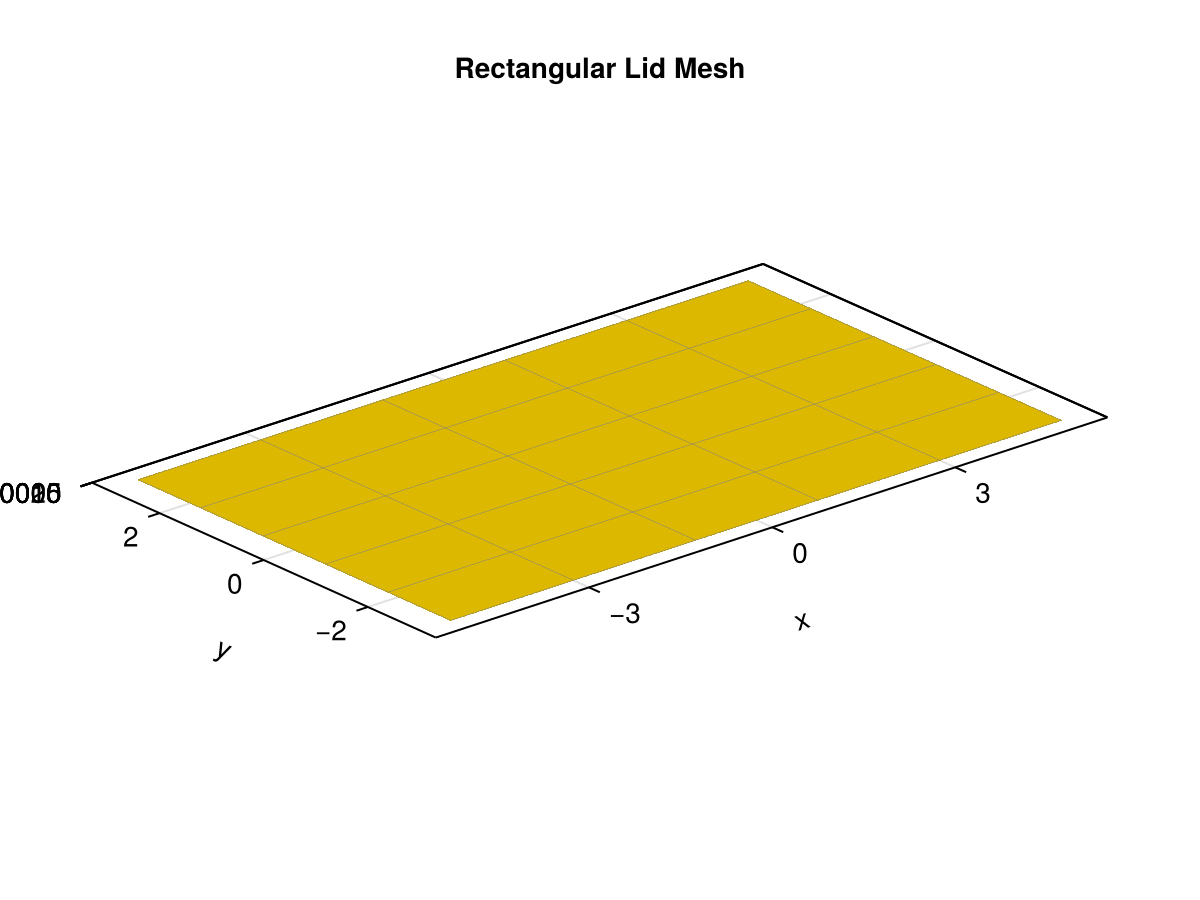

CairoMakie.Screen{IMAGE}


In [ ]:
# function rectangular_lid_mesh(x_min::Real, x_max::Real, y_min::Real, y_max::Real, n_panels_x::Int, n_panels_y::Int, z_value::Real=0.0)


#     # 2. Create a flat 2D CartesianGrid
#     start_point = Meshes.Point(x_min, y_min)
#     end_point   = Meshes.Point(x_max, y_max)
#     grid = Meshes.CartesianGrid(start_point, end_point, dims=(n_panels_x, n_panels_y))

#     # 3. Extract the 2D vertices and elevate them to 3D
#     verts2d = Meshes.vertices(grid)
    
#     verts3d = map(verts2d) do v
#         vec_coords = Meshes.to(v)
        
#         # Give z_value the exact unit (meters) that Meshes expects
#         z_with_unit = z_value * u"m"
        
#         Meshes.Point(vec_coords[1], vec_coords[2], z_with_unit)
#     end

#     # 4. Construct the SimpleMesh using the 3D vertices and the 2D grid's topology
#     return Meshes.SimpleMesh(verts3d, Meshes.topology(grid))
# end

function rectangular_lid_mesh(x_min::Real, x_max::Real, y_min::Real, y_max::Real, n_panels_x::Int, n_panels_y::Int, z_value::Real=0.0)
    # 1. Create a flat 2D CartesianGrid
    start_point = Meshes.Point(x_min, y_min)
    end_point   = Meshes.Point(x_max, y_max)
    grid = Meshes.CartesianGrid(start_point, end_point, dims=(n_panels_x, n_panels_y))

    # 2. Extract the 2D vertices and elevate them to 3D
    verts2d = Meshes.vertices(grid)
    verts3d = map(verts2d) do v
        vec_coords = Meshes.to(v)
        z_with_unit = z_value * u"m"
        Meshes.Point(vec_coords[1], vec_coords[2], z_with_unit)
    end

    # 3. Extract the connectivity indices natively from the grid elements
    # This unpacks the quad-panel connections explicitly
    connec = [Meshes.connect(Tuple(e.indices)) for e in Meshes.topology(grid)]

    # 4. Construct the SimpleMesh using an explicit unstructured configuration
    return Meshes.SimpleMesh(verts3d, connec)
end

x_min = -5
x_max = 5
y_min = -3
y_max = 3
n_panels_x = 5
n_panels_y = 5
z_value = 1e-3
lid_mesh = rectangular_lid_mesh(x_min, x_max, y_min, y_max, n_panels_x, n_panels_y, z_value)




fig = Makie.Figure()
ax = Makie.Axis3(fig[1, 1], title = "Rectangular Lid Mesh", aspect = :data)

Meshes.viz!(ax, lid_mesh, color=:gold, showsegments=true, segmentcolor=:grey50, segmentsize=0.25)
display(fig)

In [4]:
Mesh(lid_mesh)

Mesh([-5.0 -3.0 0.001; -3.0 -3.0 0.001; … ; 3.0 3.0 0.001; 5.0 3.0 0.001], [0 1 7 6; 1 2 8 7; … ; 27 28 34 33; 28 29 35 34], Number[-3.999999999999999 -2.4 0.001; -2.0000000000000004 -2.4 0.001; … ; 2.0 2.4 0.001; 4.0 2.4 0.001], Number[0.0 0.0 1.0; 0.0 0.0 1.0; … ; 0.0 0.0 1.0; 0.0 0.0 1.0], [2.4, 2.4, 2.4, 2.4, 2.4, 2.4, 2.4, 2.4, 2.4, 2.4  …  2.4000000000000004, 2.4000000000000004, 2.4000000000000004, 2.4000000000000004, 2.4000000000000004, 2.4000000000000004, 2.4000000000000004, 2.4000000000000004, 2.4000000000000004, 2.4000000000000004], Number[1.1661903789690609, 1.1661903789690597, 1.1661903789690602, 1.1661903789690604, 1.1661903789690593, 1.1661903789690609, 1.1661903789690597, 1.16619037896906, 1.1661903789690604, 1.1661903789690593  …  1.1661903789690602, 1.1661903789690602, 1.1661903789690602, 1.1661903789690602, 1.1661903789690602, 1.1661903789690602, 1.1661903789690602, 1.1661903789690602, 1.1661903789690602, 1.1661903789690602], 36, 25)

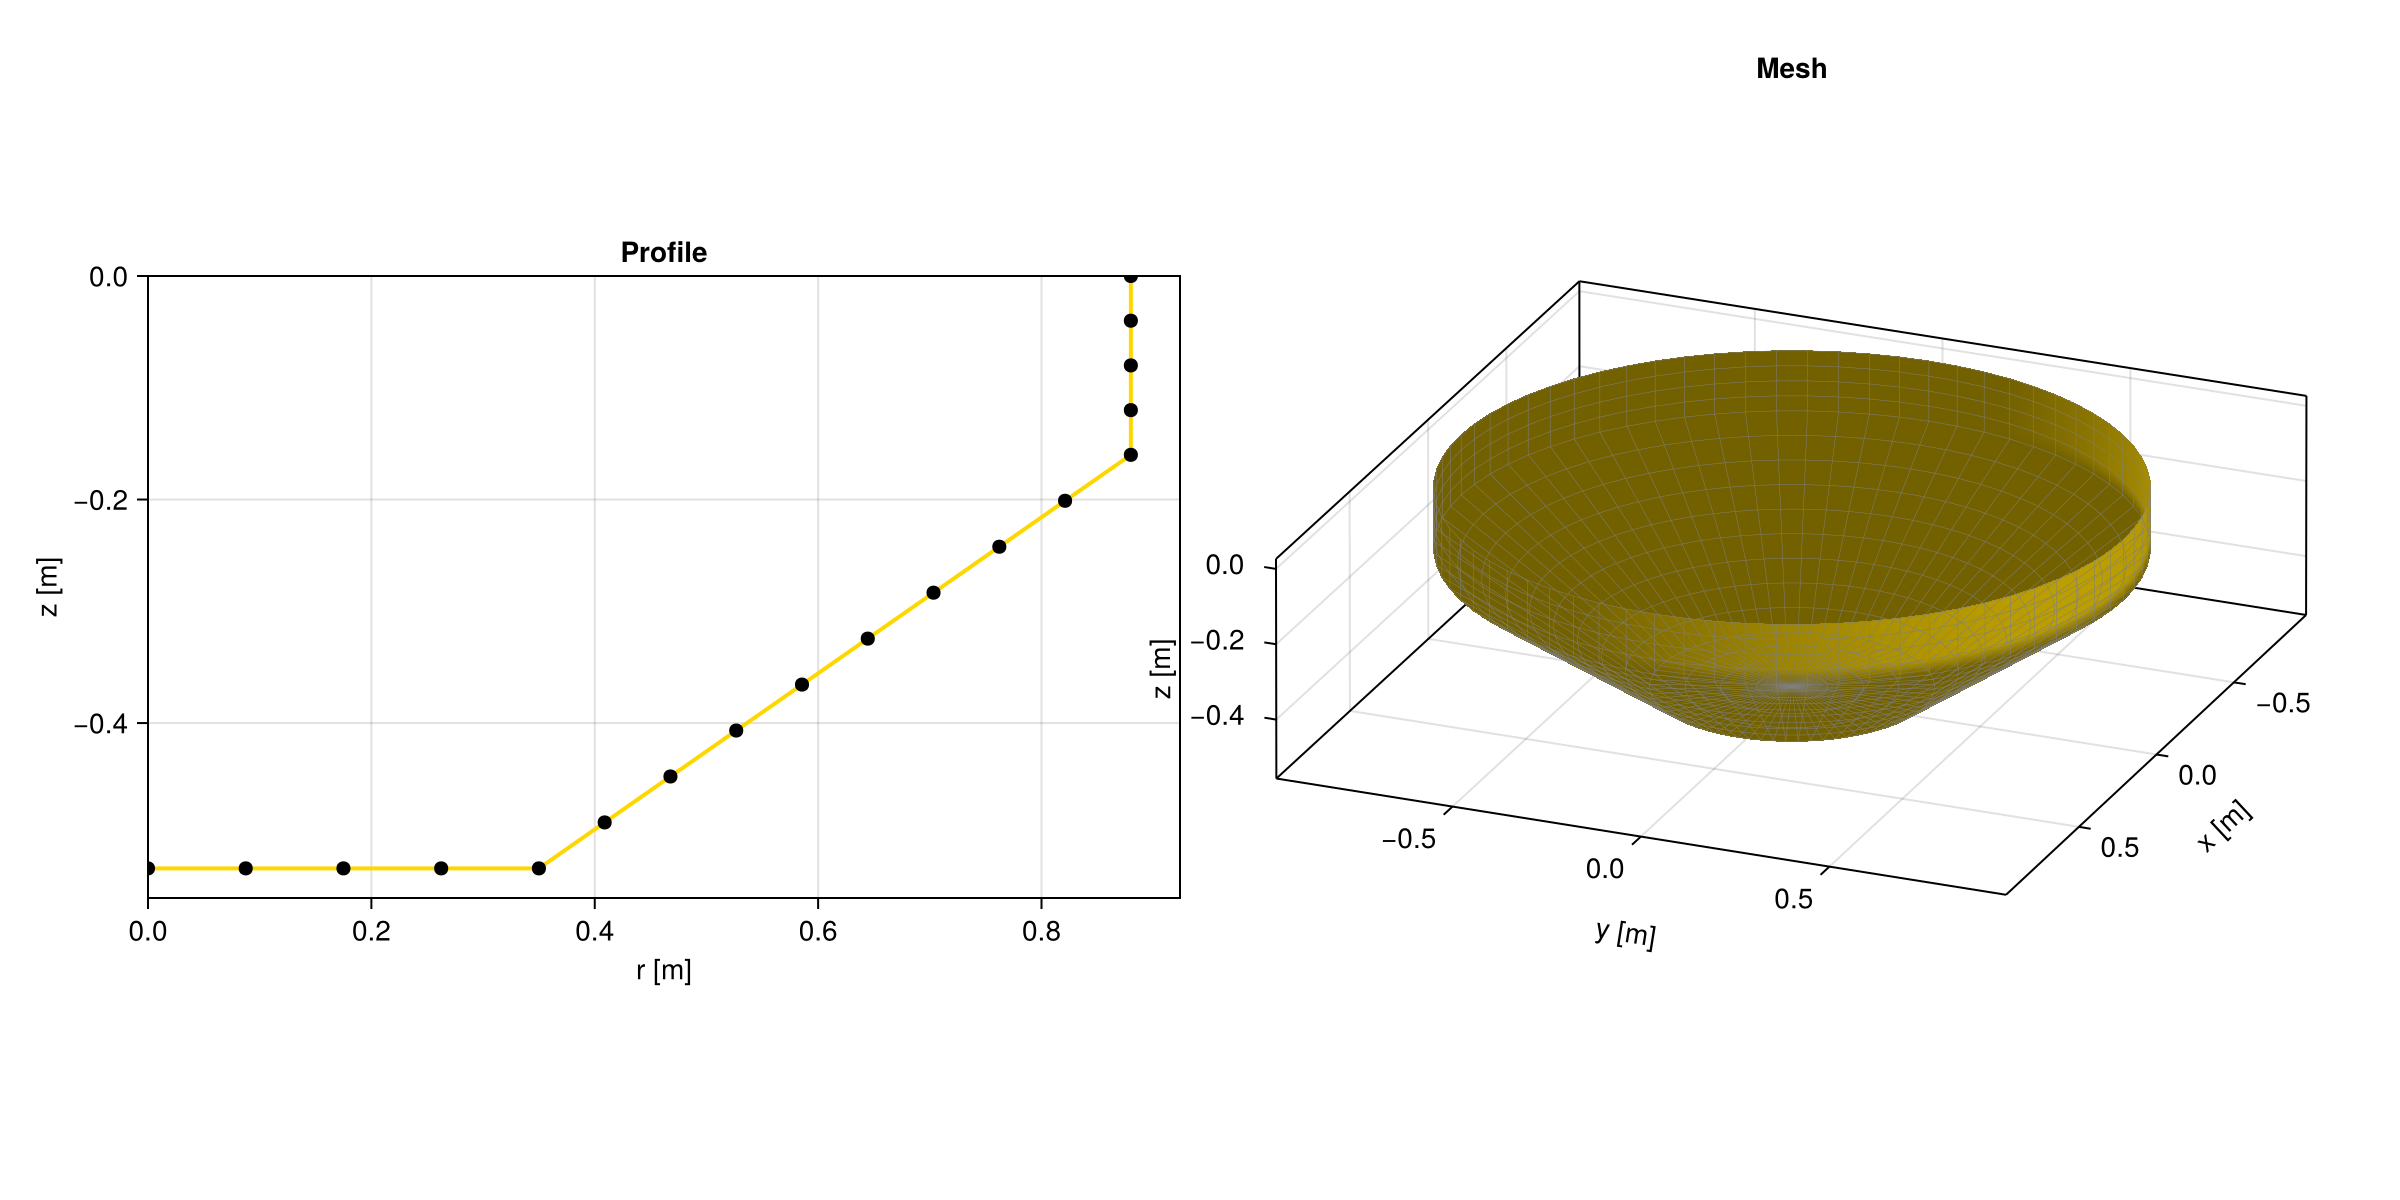

Mesh([0.88 0.0 -0.0; 0.876651334320736 0.07669705361793919 -0.0; … ; 0.08716703608302773 -0.007626127490420102 -0.53; 0.0 0.0 -0.53], [0 72 73 1; 1 73 74 2; … ; 1222 1224 1223 1223; 1223 1224 1152 1152], Number[0.8783256671603681 0.03834852680896959 -0.020000000000000004; 0.8716410784857396 0.11475372498241895 -0.020000000000000004; … ; 0.05777923815719863 -0.007606781012092169 -0.53; 0.05822234536100924 -0.002542042496806701 -0.53], Number[0.9990482215818576 0.04361938736533626 0.0; 0.9914448613738104 0.13052619222005138 0.0; … ; 0.0 0.0 -1.0; 0.0 0.0 -1.0], [0.0030708048705196545, 0.003070804870519654, 0.0030708048705196545, 0.0030708048705196537, 0.0030708048705196554, 0.0030708048705196532, 0.003070804870519656, 0.0030708048705196515, 0.0030708048705196545, 0.0030708048705196576  …  0.00033364307770587847, 0.00033364307770587825, 0.0003336430777058785, 0.000333643077705882, 0.00033364307770587527, 0.0003336430777058817, 0.00033364307770587884, 0.0003336430777058783, 0.0003336430777

In [5]:
r1 = 0.88
r2 = 0.35
d1 = 0.16
d2 = 0.37
n_points = (5, 10, 5)
n_theta = 72
show_plot = true

mhmesh = wavebot_mesh(r1,r2,d1,d2,n_points,n_theta,show_plot)

In [6]:
isnothing(nothing)

true

In [12]:
1:10:100

1:10:91

In [23]:
function generate_lid(x_min_lid::Real, x_max_lid::Real, y_min_lid::Real, y_max_lid::Real, z_value::Real, faces_max_radius::Real, show_lid::Bool=false)

    n_panels_x = Int(ceil((x_max-x_min)/(2*faces_max_radius)))
    n_panels_y = Int(ceil((y_max-y_min)/(2*faces_max_radius)))

    mesh = rectangular_lid_mesh(x_min_lid, x_max_lid, y_min_lid, y_max_lid, n_panels_x, n_panels_y, z_value)
    if show_lid
        fig = Makie.Figure()
        ax = Makie.Axis3(fig[1, 1], title = "Rectangular Lid Mesh", aspect = :data)
        Meshes.viz!(ax, mesh, color=:gold, showsegments=true, segmentcolor=:grey50, segmentsize=0.25)
        display(fig)
    end
    return Mesh(mesh)
end

function generate_lid(x_min_lid::Real, x_max_lid::Real, y_min_lid::Real, y_max_lid::Real, z_value::Real, faces_max_radius::Real)
    return generate_lid(x_min_lid, x_max_lid, y_min_lid, y_max_lid, z_value, faces_max_radius, false)
end



generate_lid (generic function with 5 methods)

In [ ]:
# function generate_lid(MH_mesh, n_panels_x, n_panels_x, z_value)


#     z_value = 1e-3
# lid_mesh = rectangular_lid_mesh(width, width, n_panels_x, n_panels_x, z_value)


#     return
# end

In [24]:
Int(round(0.1))

0

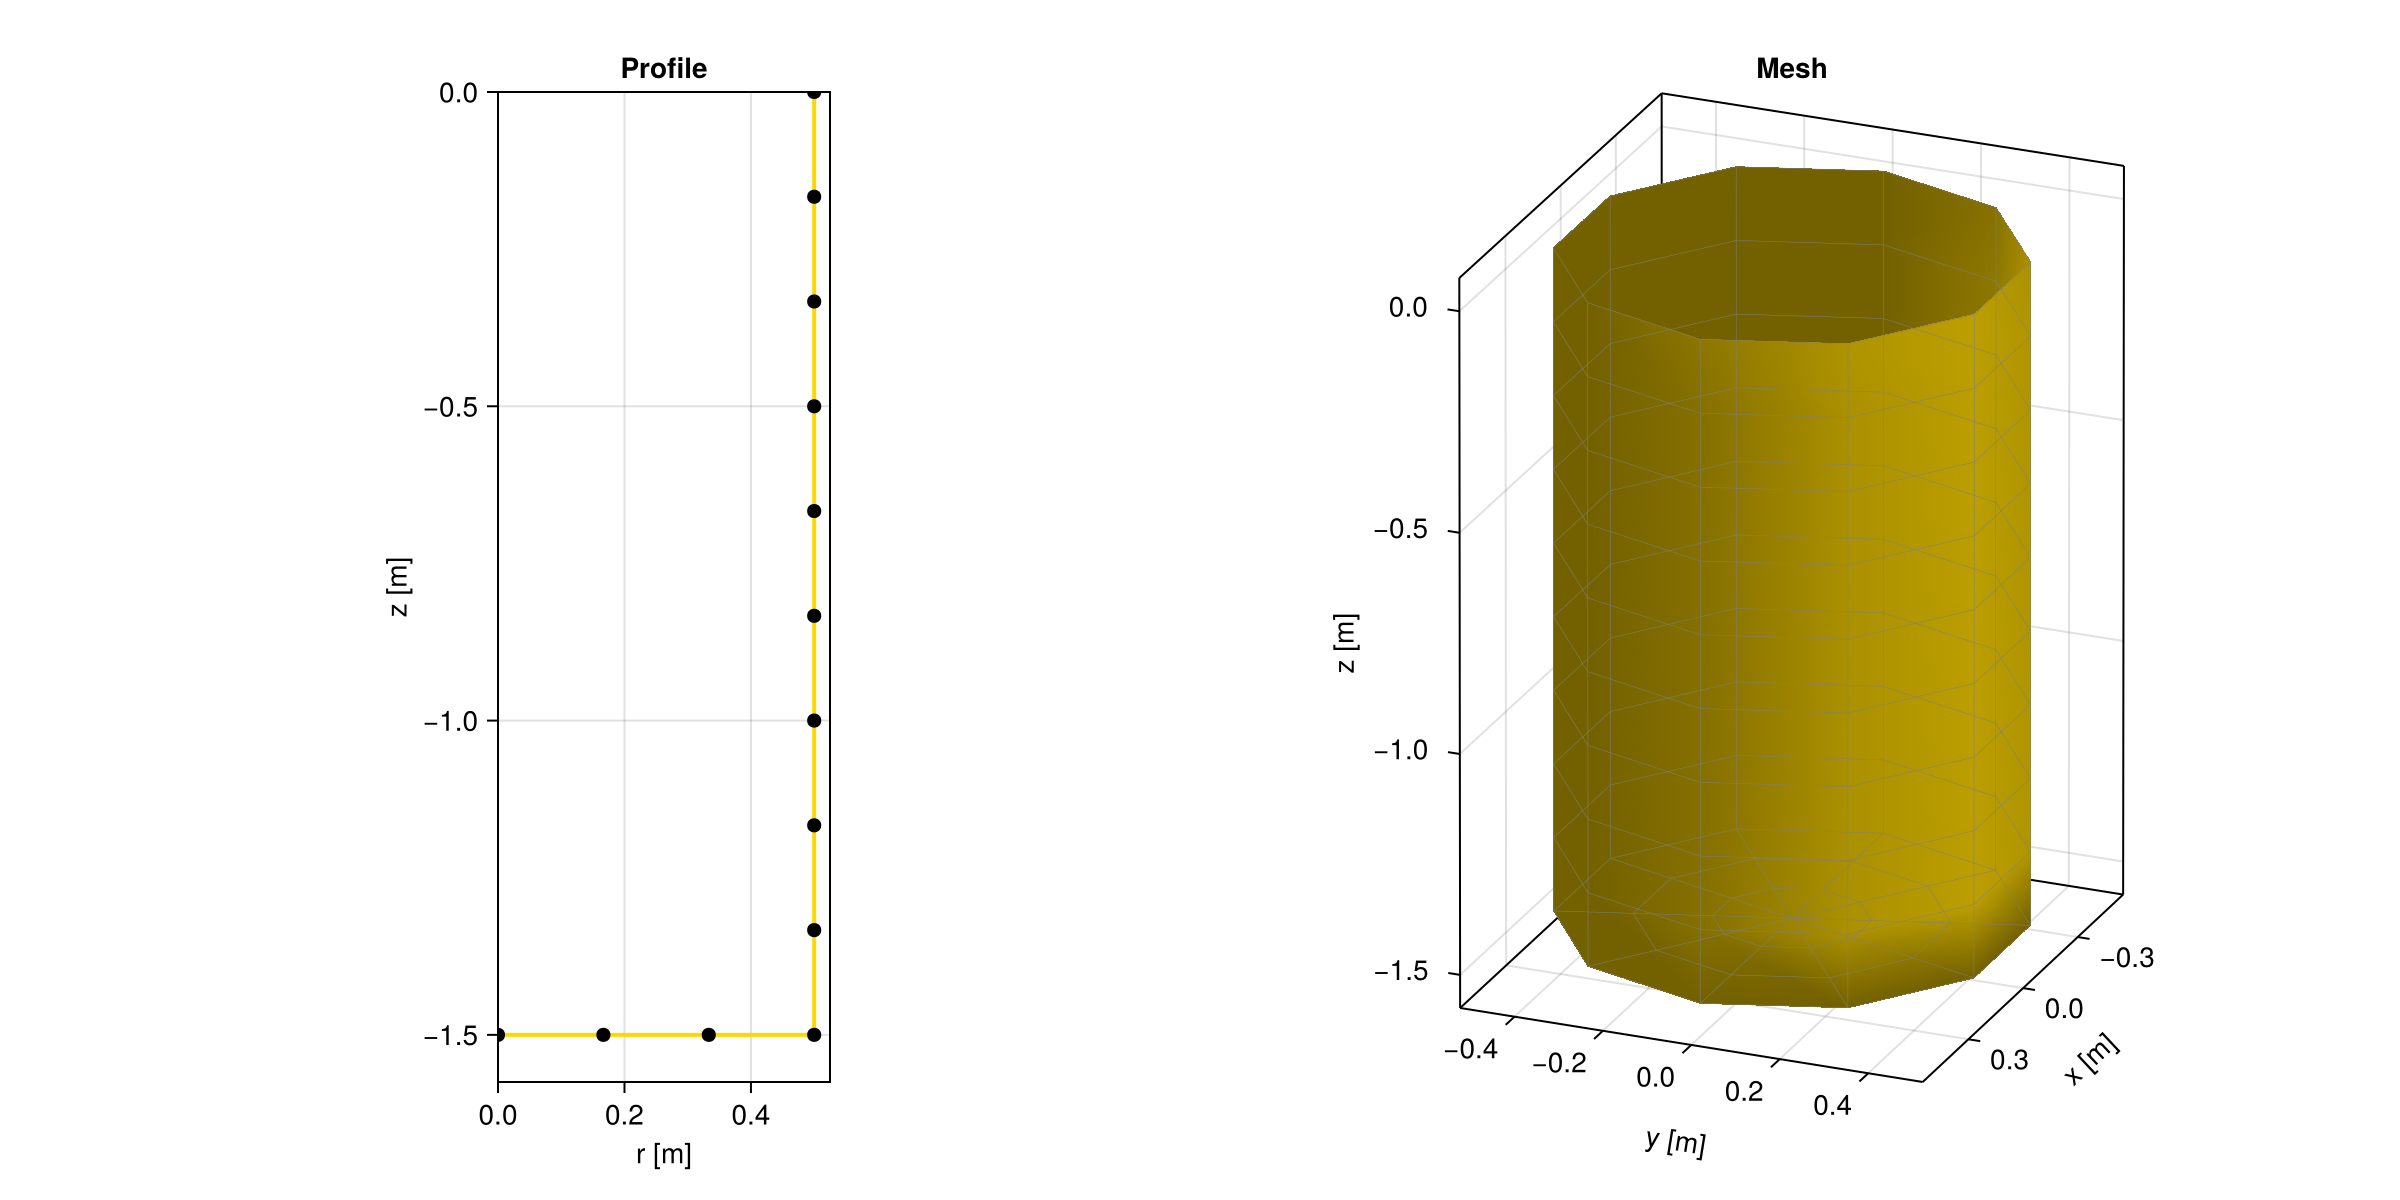

Mesh([0.5 0.0 0.0; 0.4045084971874737 0.29389262614623657 0.0; … ; 0.13483616572915788 -0.09796420871541223 -1.5; 0.0 0.0 -1.5], [0 10 11 1; 1 11 12 2; … ; 118 120 119 119; 119 120 110 110], Number[0.4522542485937368 0.14694631307311828 -0.08333333333333333; 0.2795084971874738 0.38471044214690675 -0.08333333333333333; … ; 0.06211299937499414 -0.08549120936597927 -1.5; 0.10050094413194151 -0.03265473623847074 -1.5], Number[0.9510565162951536 0.3090169943749474 0.0; 0.587785252292473 0.8090169943749475 0.0; … ; 0.0 0.0 -1.0; 0.0 0.0 -1.0], [0.051502832395824566, 0.051502832395824566, 0.051502832395824566, 0.051502832395824566, 0.05150283239582457, 0.051502832395824566, 0.051502832395824566, 0.051502832395824566, 0.051502832395824566, 0.05150283239582459  …  0.008163684059617681, 0.008163684059617683, 0.008163684059617681, 0.008163684059617681, 0.008163684059617681, 0.008163684059617681, 0.008163684059617681, 0.008163684059617681, 0.008163684059617681, 0.008163684059617685], Number[0.1755

In [25]:

r_initial = 0.5
n_side = 10 # number of design vars-1 (draft is also a design var)

# inputs
r_side = ones(n_side) * r_initial
# r_side = collect(range(0.5, 0.001, length=n_side)) # last radius cannot be zero
draft = 1.5
x = vcat(r_side,draft)


function arbitrary_axisymmetric_mesh(x::Vector, show_plot)

    r_side = x[1:end-1]
    draft = x[end]
    n_side = length(r_side)

    z_side = collect(range(-0.0, -draft, length=n_side))

    panel_z_len = abs(z_side[1]-z_side[2])
    last_z = z_side[end]

    n_bottom = 3

    z_bottom = ones(n_bottom) * (-draft)
    r_bottom = collect(range(r_side[end], 0.0, length=n_bottom+1))[2:end]

    z_vals = vcat(z_side, z_bottom)
    r_vals = vcat(r_side, r_bottom)

    n_theta = 10

    MH_mesh = axisymmetric_mesh(r_vals,z_vals,n_theta,show_plot)

    return MH_mesh
end

arbitrary_axisymmetric_mesh(x::Vector) = arbitrary_axisymmetric_mesh(x, false)

arbitrary_axisymmetric_mesh(x, true)

In [26]:
MH_mesh = arbitrary_axisymmetric_mesh(x)

Mesh([0.5 0.0 0.0; 0.4045084971874737 0.29389262614623657 0.0; … ; 0.13483616572915788 -0.09796420871541223 -1.5; 0.0 0.0 -1.5], [0 10 11 1; 1 11 12 2; … ; 118 120 119 119; 119 120 110 110], Number[0.4522542485937368 0.14694631307311828 -0.08333333333333333; 0.2795084971874738 0.38471044214690675 -0.08333333333333333; … ; 0.06211299937499414 -0.08549120936597927 -1.5; 0.10050094413194151 -0.03265473623847074 -1.5], Number[0.9510565162951536 0.3090169943749474 0.0; 0.587785252292473 0.8090169943749475 0.0; … ; 0.0 0.0 -1.0; 0.0 0.0 -1.0], [0.051502832395824566, 0.051502832395824566, 0.051502832395824566, 0.051502832395824566, 0.05150283239582457, 0.051502832395824566, 0.051502832395824566, 0.051502832395824566, 0.051502832395824566, 0.05150283239582459  …  0.008163684059617681, 0.008163684059617683, 0.008163684059617681, 0.008163684059617681, 0.008163684059617681, 0.008163684059617681, 0.008163684059617681, 0.008163684059617681, 0.008163684059617681, 0.008163684059617685], Number[0.1755

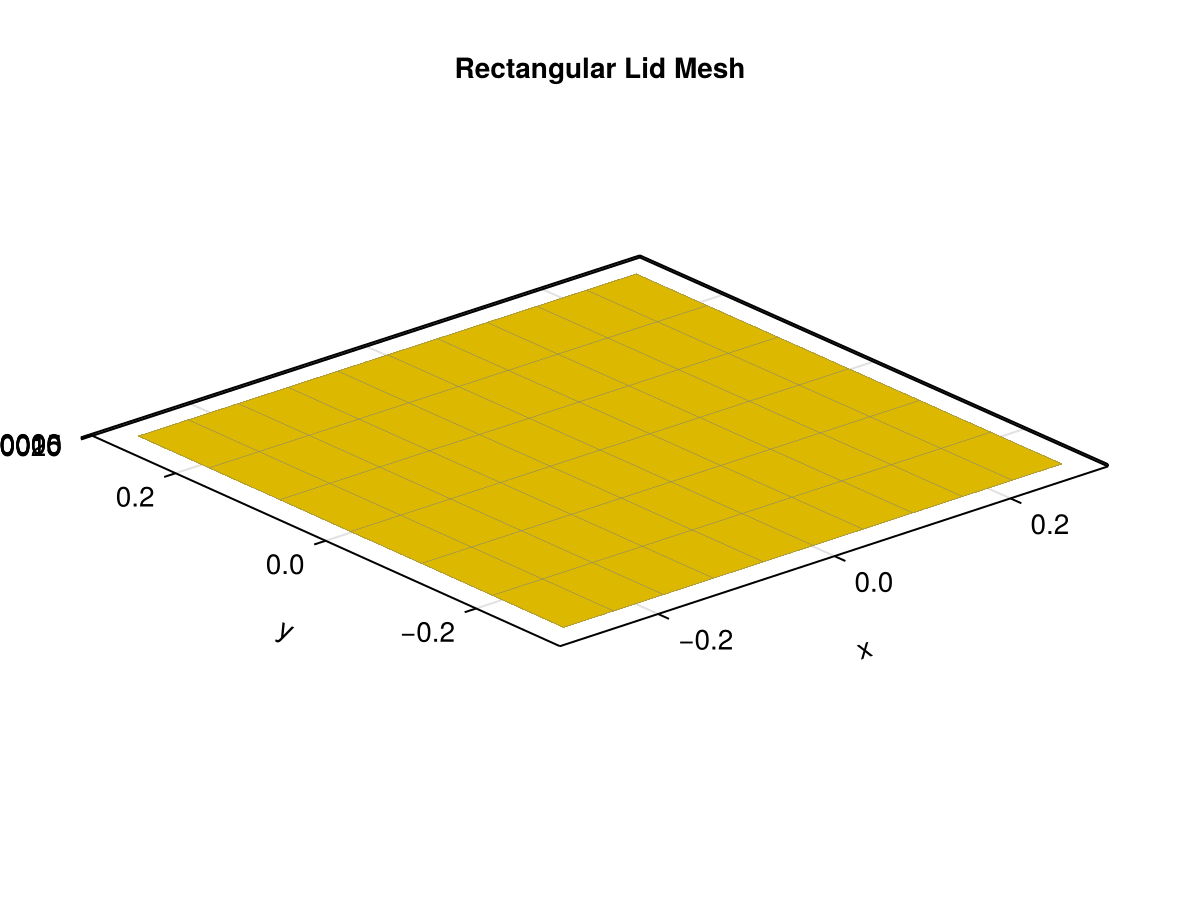

Mesh([-0.282842712474619 -0.282842712474619 -0.001; -0.2262741699796952 -0.282842712474619 -0.001; … ; 0.22627416997969518 0.282842712474619 -0.001; 0.282842712474619 0.282842712474619 -0.001], [0 1 12 11; 1 2 13 12; … ; 63 64 75 74; 64 65 76 75], Number[-0.2545584412271571 -0.23570226039551584 -0.001; -0.19798989873223333 -0.23570226039551584 -0.001; … ; 0.19798989873223333 0.23570226039551584 -0.001; 0.2545584412271571 0.23570226039551587 -0.001], Number[0.0 0.0 1.0; 0.0 0.0 1.0; … ; 0.0 0.0 1.0; 0.0 0.0 1.0], [0.005333333333333332, 0.005333333333333332, 0.005333333333333335, 0.005333333333333332, 0.005333333333333332, 0.005333333333333335, 0.00533333333333333, 0.005333333333333335, 0.00533333333333333, 0.005333333333333335  …  0.005333333333333332, 0.005333333333333332, 0.005333333333333335, 0.005333333333333332, 0.005333333333333332, 0.005333333333333335, 0.00533333333333333, 0.005333333333333335, 0.00533333333333333, 0.005333333333333335], Number[0.05497474167490215, 0.05497474167

In [28]:
radius_at_surface = maximum(r_side)
x_mean = 0.0
y_mean = 0.0
reduce_scale = 0.8
width = radius_at_surface * (2/sqrt(2)) * reduce_scale
x_min_lid = x_mean - width/2
x_max_lid = x_mean + width/2
y_min_lid = y_mean - width/2
y_max_lid = y_mean + width/2
z_value = -1e-3
faces_max_radius = 0.5

wb_lid = generate_lid(x_min_lid, x_max_lid, y_min_lid, y_max_lid, z_value, faces_max_radius,true)



In [41]:
MH_mesh.vertices[:,3]

121-element Vector{Float64}:
 -0.001
 -0.001
 -0.001
 -0.001
 -0.001
 -0.001
 -0.001
 -0.001
 -0.001
 -0.001
  ⋮
 -1.5
 -1.5
 -1.5
 -1.5
 -1.5
 -1.5
 -1.5
 -1.5
 -1.5

In [15]:
function hydrostatic_program(x)
    r_side = x[1:end-1]
    draft = x[end]
    n_side = length(r_side)
    
    z_side = range(-1e-3, -draft, length=n_side)

    rho_w = 1025.0 
    g = 9.81 
    K = rho_w * g * pi * r_side[1]^2 


    volume = 0.0
    for i in 1:(n_side-1)
        h_mid = abs(z_side[i] - z_side[i+1])
        r1 = r_side[i]
        r2 = r_side[i+1]

        volume += (pi * h_mid / 3) * (r1^2 + r1 * r2 + r2^2)
    end
    
    M = rho_w * volume 

    return [M, K]
end

hydrostatic_program (generic function with 1 method)

In [16]:
hydrostatic_program(x)

2-element Vector{Float64}:
 1206.7446431060944
 7897.374882502192

In [17]:
pi*(0.5^2)*1.5 * 1025

1207.5496762235766

In [9]:
# using CairoMakie
# function plot_mesh(mesh::Meshes.SimpleMesh, profile)

#     profile_r = [ustrip.(v.coords.x) for v in profile.vertices]
#     profile_z = [ustrip.(v.coords.y) for v in profile.vertices]

#     fig = Makie.Figure(size=(600, 600));
#     # ax = Makie.Axis(
#     #     fig[1, 1];
#     #     aspect=Makie.DataAspect(),
#     #     xlabel="r [m]",
#     #     ylabel="z [m]",
#     #     xlabelsize = 30,     
#     #     ylabelsize = 30,
#     #     limits=((0, nothing), (nothing, 1e-6)),
#     # );
#     # Makie.lines!(ax, profile_r, profile_z, color=:gold, linewidth=2);
#     # Makie.scatter!(ax, profile_r, profile_z, color=:black, markersize=10);

#     ax = Makie.Axis3(
#         fig[1, 1];
#         aspect=:data,
#         azimuth=π / 8,
#         elevation=π / 16,
#         xlabel="x [m]",
#         ylabel="y [m]",
#         zlabel="z [m]",
#         xlabelsize = 30,     
#         ylabelsize = 30,
#         zlabelsize = 30,
#     );
#     hidedecorations!(ax) 
#     hidespines!(ax)
#     # colgap!(fig.layout, 1, 50)
#     Meshes.viz!(ax, mesh, color=:gold, showsegments=true, segmentcolor=:black, segmentsize=0.25);

#     display(fig)

#     save("wavebot_plot.png", fig, pt_per_unit = 10.0)
# end